In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os


In [2]:
dataset_path = r"E:\data"

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.


In [4]:
class_names = train_ds.class_names
print(class_names)

['with_mask', 'without_mask']


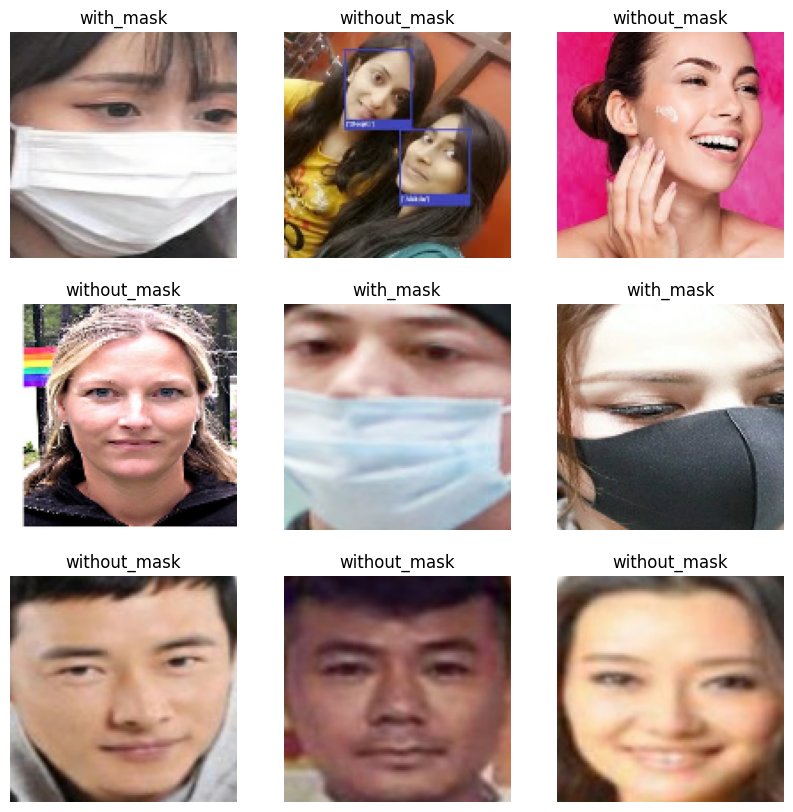

In [5]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [6]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [8]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(2, activation='softmax')
])

D:\python\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,898 (12.61 MB)

 Trainable params: 3,304,898 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100


D:\python\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 138ms/step - accuracy: 0.8524 - loss: 0.3500 - val_accuracy: 0.8960 - val_loss: 0.2986
Epoch 2/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.9082 - loss: 0.2309 - val_accuracy: 0.9377 - val_loss: 0.1746
Epoch 3/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.9406 - loss: 0.1738 - val_accuracy: 0.9417 - val_loss: 0.1475
Epoch 4/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.9482 - loss: 0.1337 - val_accuracy: 0.9430 - val_loss: 0.1507
Epoch 5/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 26s 136ms/step - accuracy: 0.9576 - loss: 0.1195 - val_accuracy: 0.9523 - val_loss: 0.1392
Epoch 6/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 26s 135ms/step - accuracy: 0.9691 - loss: 0.0901 - val_accuracy: 0.9603 - val_loss: 0.1197
Epoch 7/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.9740 - loss: 0.0727 - val_accuracy: 0.9636 - val_loss: 0.1120
Epoch 8/100
189/189 ━━━━━━━━━━━━━━━━━━━━ 27s 141ms/step - accuracy: 0.9772 - loss: 0.062

In [11]:
model.save("face_mask_model.keras")
print("Model saved successfully!")

Model saved successfully!


In [14]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("face_mask_model.keras")

# Class names
class_names = ['with_mask', 'without_mask']

# Image path
img_path = "E:\data\with_mask\with_mask_3.jpg"   # Change this to your test image

# Load image
img = image.load_img(img_path, target_size=(128, 128))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print("Prediction:", class_names[predicted_class])
print("Confidence:", prediction[0][predicted_class] * 100)

# # Show image
# plt.imshow(img)
# plt.title(class_names[predicted_class])
# plt.axis("off")
# plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22920\3161868863.py:13: SyntaxWarning: invalid escape sequence '\d'
  img_path = "E:\data\with_mask\with_mask_3.jpg"   # Change this to your test image


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Prediction: with_mask
Confidence: 100.0


In [1]:
import cv2
import numpy as np
import tensorflow as tf
# Load trained model
model = tf.keras.models.load_model("face_mask_model.keras")

# Class labels
class_names = ["without_mask","with_mask"]

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open webcam")

while True:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.3,
        minNeighbors=5
    )

    for (x, y, w, h) in faces:

        face = frame[y:y+h, x:x+w]
        face = cv2.resize(face, (128, 128))
        face = face.astype("float32") / 255.0
        face = np.expand_dims(face, axis=0)

        prediction = model.predict(face, verbose=0)

        class_index = np.argmax(prediction)
        confidence = prediction[0][class_index]

        label = class_names[class_index]

        if label == "with_mask":
            color = (0, 255, 0)
            text = f"Mask {confidence*100:.2f}%"
        else:
            color = (0, 0, 255)
            text = f"No Mask {confidence*100:.2f}%"

        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)

        cv2.putText(
            frame,
            text,
            (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            color,
            2
        )

    cv2.imshow("Face Mask Detection", frame)

    # Press q to quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()